In [ ]:
import pandas as pd

#Load data
df_train = pd.read_csv("./data/claims_train_clean.csv")
df_test = pd.read_csv("./data/claims_test_clean.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

#Drop ID column
for df in (df_train, df_test):
    if "IDpol" in df.columns:
        df.drop(columns=["IDpol"], inplace=True)

#Encode area to int
area_labels = sorted(df_train["Area"].unique())
area_to_int = {label: i for i, label in enumerate(area_labels)}
print("Area mapping:", area_to_int)

df_train["Area_enc"] = df_train["Area"].map(area_to_int)
df_test["Area_enc"] = df_test["Area"].map(area_to_int)

#features and target
numeric_features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density",
]

categorical_features = [
    "Area_enc",
]

feature_cols = numeric_features + categorical_features

X_train = df_train[feature_cols].to_numpy(dtype=float)
y_train = df_train["ClaimNb"].to_numpy(dtype=float)

X_test = df_test[feature_cols].to_numpy(dtype=float)

y_test = df_test["ClaimNb"].to_numpy(dtype=float)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape)


Train shape: (541416, 13)
Test shape: (135373, 13)
Area mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
X_train: (541416, 7) y_train: (541416,)
X_test: (135373, 7)


In [18]:
import numpy as np

# hyperparameters for the tree(adjust based on hyperparameter grid search in the end of file)
max_depth = 8
min_samples_split = 100
min_samples_leaf = 50

X_tr = X_train.copy().astype(float)
y_tr = y_train.copy().astype(float)

n_samples, n_features = X_tr.shape
feature_indices = np.arange(n_features)

#tree as parallel lists
node_prediction = [] # mean y in node
node_feature = [] # feature index used for split
node_threshold = [] # threshold value
node_left = [] #index of left child node
node_right = [] # index of right child node
node_depth = [] # depth of node
node_is_leaf = [] # True/False
node_samples_ix = [] # which training rows belong to this node

# create root node
root_idx = 0
node_prediction.append(y_tr.mean())
node_feature.append(np.nan)
node_threshold.append(np.nan)
node_left.append(np.nan)
node_right.append(np.nan)
node_depth.append(0)
node_is_leaf.append(False)# might be split later
node_samples_ix.append(np.arange(n_samples))

#queue of nodes that we still try to split
nodes_to_process = [root_idx]

while len(nodes_to_process) > 0:
    node_id = nodes_to_process.pop()
    depth = node_depth[node_id]
    idx = node_samples_ix[node_id]
    X_node = X_tr[idx]
    y_node = y_tr[idx]
    n_node = len(idx)

    # stopping conditions
    if depth >= max_depth or n_node < min_samples_split or np.all(y_node == y_node[0]):
        node_is_leaf[node_id] = True
        continue

    best_feature = None
    best_threshold = None
    best_loss = np.inf

    # search over all features
    for f in feature_indices:
        col = X_node[:, f]
        unique_vals = np.unique(col)
        if unique_vals.size <= 1:
            continue

        # candidate thresholds: midpoints between sorted unique values
        thresholds = (unique_vals[:-1]+unique_vals[1:])/2.0

        for thr in thresholds:
            left_mask = col <= thr
            right_mask = col > thr

            n_left = left_mask.sum()
            n_right = right_mask.sum()

            # skip splits that make tiny leaves
            if n_left < min_samples_leaf or n_right < min_samples_leaf:
                continue

            y_left = y_node[left_mask]
            y_right = y_node[right_mask]

            # weighted sum of variances = proxy for MSE
            loss_left = np.var(y_left) * n_left
            loss_right = np.var(y_right) * n_right
            loss = loss_left + loss_right

            if loss < best_loss:
                best_loss = loss
                best_feature = f
                best_threshold = thr

    # if we did not find any valid split, make the node a leaf
    if best_feature is None:
        node_is_leaf[node_id] = True
        continue

    # create children nodes
    col_full = X_tr[idx][:, best_feature]
    left_mask_full = col_full <= best_threshold
    right_mask_full = ~left_mask_full

    left_idx = idx[left_mask_full]
    right_idx = idx[right_mask_full]

    # left child
    left_node_id = len(node_prediction)
    node_prediction.append(y_tr[left_idx].mean())
    node_feature.append(np.nan)
    node_threshold.append(np.nan)
    node_left.append(np.nan)
    node_right.append(np.nan)
    node_depth.append(depth + 1)
    node_is_leaf.append(False)
    node_samples_ix.append(left_idx)

    # right child
    right_node_id = len(node_prediction)
    node_prediction.append(y_tr[right_idx].mean())
    node_feature.append(np.nan)
    node_threshold.append(np.nan)
    node_left.append(np.nan)
    node_right.append(np.nan)
    node_depth.append(depth + 1)
    node_is_leaf.append(False)
    node_samples_ix.append(right_idx)

    # update current node with split info and links
    node_feature[node_id] = best_feature
    node_threshold[node_id] = best_threshold
    node_left[node_id] = left_node_id
    node_right[node_id] = right_node_id

    # schedule children for further splitting
    nodes_to_process.append(left_node_id)
    nodes_to_process.append(right_node_id)

print("Number of nodes in tree:", len(node_prediction))
print("Number of leaves:", sum(node_is_leaf))


Number of nodes in tree: 413
Number of leaves: 207


In [19]:
#function-less prediction loop for one matrix X
def tree_predict_matrix(X_mat):
    X_mat = np.asarray(X_mat, dtype=float)
    n = X_mat.shape[0]
    preds = np.zeros(n, dtype=float)

    for i in range(n):
        x = X_mat[i]
        node_id = 0
        while not node_is_leaf[node_id]:
            f = node_feature[node_id]
            thr = node_threshold[node_id]
            if x[f] <= thr:
                node_id = node_left[node_id]
            else:
                node_id = node_right[node_id]
        preds[i] = node_prediction[node_id]
    return preds

# predictions on train and test
y_pred_train = tree_predict_matrix(X_train)
if y_test is not None:
    y_pred_test = tree_predict_matrix(X_test)

# RMSE calculation
train_rmse = np.sqrt(np.mean((y_train - y_pred_train) ** 2))
print("Train RMSE:", train_rmse)

if y_test is not None:
    test_rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
    print("Test RMSE:", test_rmse)


Train RMSE: 0.2350264313929303
Test RMSE: 0.24211084329223362


With using libraries

In [20]:
import numpy as np
#baseline:
baseline_pred_train = np.full_like(y_train, y_train.mean(), dtype=float)

if y_test is not None:
    baseline_pred_test = np.full_like(y_test, y_train.mean(), dtype=float)

baseline_train_rmse = np.sqrt(np.mean((y_train - baseline_pred_train) ** 2))
print("Baseline train RMSE:", baseline_train_rmse)

if y_test is not None:
    baseline_test_rmse = np.sqrt(np.mean((y_test - baseline_pred_test) ** 2))
    print("Baseline test RMSE:", baseline_test_rmse)


Baseline train RMSE: 0.23882944848129875
Baseline test RMSE: 0.2453933119619253


In [21]:
from sklearn.tree import DecisionTreeRegressor

#hyperparameters
dt_ref = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)

dt_ref.fit(X_train, y_train)

y_pred_train_ref = dt_ref.predict(X_train)
if y_test is not None:
    y_pred_test_ref = dt_ref.predict(X_test)

train_rmse_ref = np.sqrt(np.mean((y_train - y_pred_train_ref) ** 2))
print("sklearn tree train RMSE:", train_rmse_ref)

if y_test is not None:
    test_rmse_ref = np.sqrt(np.mean((y_test - y_pred_test_ref) ** 2))
    print("sklearn tree test RMSE:", test_rmse_ref)


sklearn tree train RMSE: 0.2350264313929303
sklearn tree test RMSE: 0.24211084329223362


In [22]:
n_show = 10

print("idx | y_true | y_pred_scratch | y_pred_sklearn")
for i in range(n_show):
    print(
        i,
        float(y_test[i]),
        float(y_pred_test[i]),
        float(y_pred_test_ref[i])
    )


idx | y_true | y_pred_scratch | y_pred_sklearn
0 0.0 0.0642818315348762 0.0642818315348762
1 0.0 0.03180116378727051 0.03180116378727051
2 0.0 0.1295971978984238 0.1295971978984238
3 0.0 0.017620232172470978 0.017620232172470978
4 0.0 0.02178002178002178 0.02178002178002178
5 0.0 0.038305493621842907 0.038305493621842907
6 0.0 0.0607621009268795 0.0607621009268795
7 0.0 0.038305493621842907 0.038305493621842907
8 0.0 0.041237113402061855 0.041237113402061855
9 0.0 0.04241435562805873 0.04241435562805873


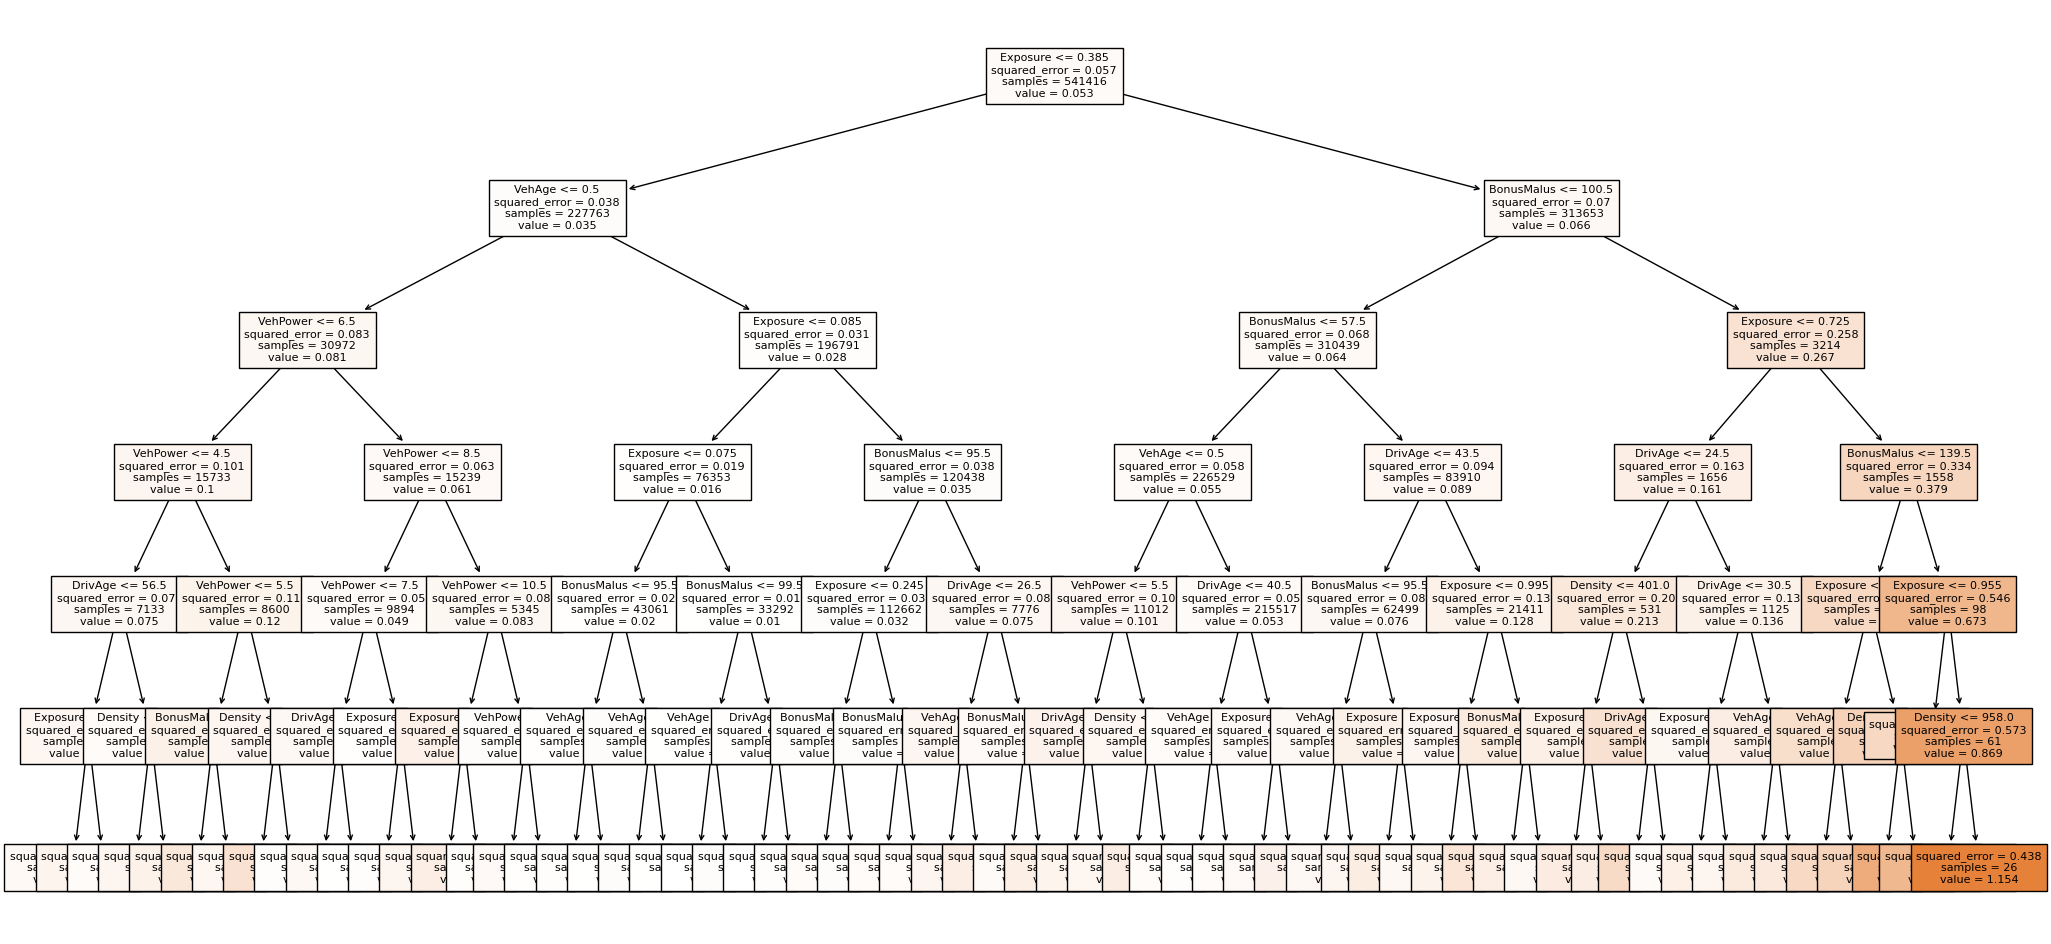

In [9]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 12))
tree.plot_tree(dt_ref, feature_names=feature_cols, filled=True, fontsize=8)
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

depth_values = [4, 6, 8, 10]
min_split_values = [20, 50, 100]
min_leaf_values = [10, 20, 50]

results = []

for depth in depth_values:
    for min_split in min_split_values:
        for min_leaf in min_leaf_values:

            #define the model with given hyperparameters
            dt = DecisionTreeRegressor(
                criterion="squared_error",
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )

            #fit the model
            dt.fit(X_train, y_train)

            #predictions on train and test
            pred_train = dt.predict(X_train)
            pred_test  = dt.predict(X_test)

            #RMSE
            rmse_train = np.sqrt(np.mean((y_train - pred_train)**2))
            rmse_test  = np.sqrt(np.mean((y_test  - pred_test )**2))

            results.append((depth, min_split, min_leaf, rmse_train, rmse_test))

            print(
                "depth =", depth,
                "| min_split =", min_split,
                "| min_leaf =", min_leaf,
                "| train_RMSE =", round(rmse_train, 6),
                "| test_RMSE =", round(rmse_test, 6)
            )


depth = 4 | min_split = 20 | min_leaf = 10 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 20 | min_leaf = 20 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 20 | min_leaf = 50 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 50 | min_leaf = 10 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 50 | min_leaf = 20 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 50 | min_leaf = 50 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 100 | min_leaf = 10 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 100 | min_leaf = 20 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 4 | min_split = 100 | min_leaf = 50 | train_RMSE = 0.236565 | test_RMSE = 0.24311
depth = 6 | min_split = 20 | min_leaf = 10 | train_RMSE = 0.235746 | test_RMSE = 0.242508
depth = 6 | min_split = 20 | min_leaf = 20 | train_RMSE = 0.235755 | test_RMSE = 0.242535
depth = 6 | min_

In [17]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "min_samples_split", "min_samples_leaf",
             "train_RMSE", "test_RMSE"]
)

# sort by test RMSE (ascending -> best first)
results_df.sort_values("test_RMSE").head(10)


,max_depth,min_samples_split,min_samples_leaf,train_RMSE,test_RMSE
26,8,100,50,0.235026,0.242111
23,8,50,50,0.235026,0.242111
20,8,20,50,0.235026,0.242111
25,8,100,20,0.235009,0.242155
24,8,100,10,0.234999,0.242157
35,10,100,50,0.234302,0.242197
32,10,50,50,0.234302,0.242197
29,10,20,50,0.234302,0.242197
21,8,50,10,0.234908,0.242242
18,8,20,10,0.234853,0.242248
